In [60]:
!pip install datasets
!pip install pyopenjtalk #for mora count
!pip install fugashi[unidic-lite] #automatically downloads and sets up UniDic behind the scenes

In [61]:
import pyopenjtalk
import pandas as pd
import datasets
from datasets import load_dataset, DatasetDict
from IPython.display import display
import fugashi
from fugashi import Tagger

Dataset description from the [HuggingFace dataset](https://huggingface.co/datasets/p1atdev/modern_haiku#data-instances) :

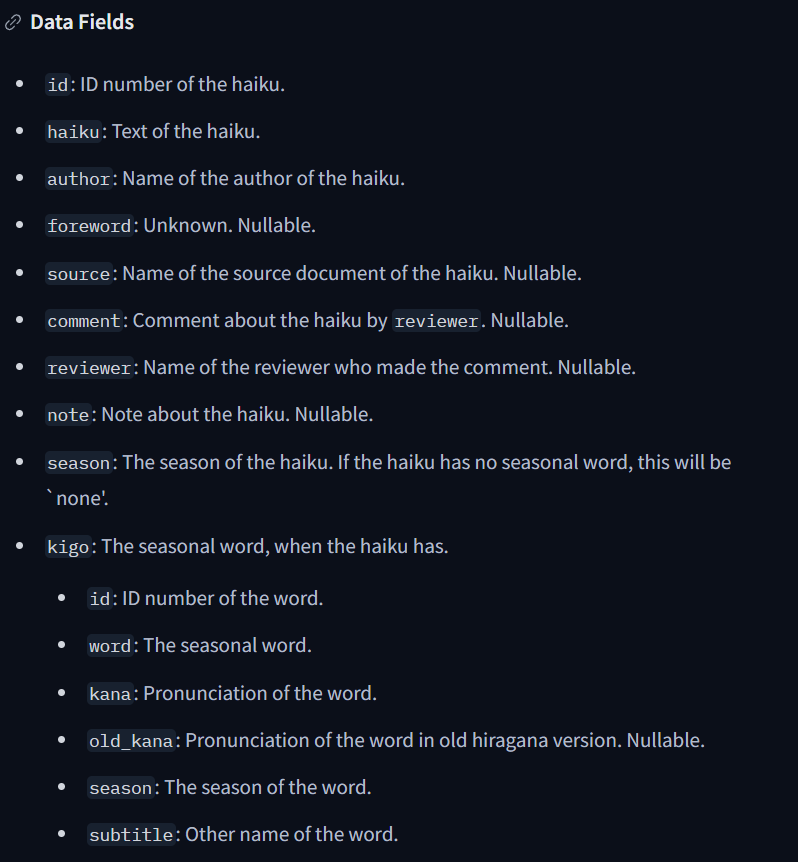

### ***Import dataset from HugginFace***

In [62]:
dataset = load_dataset(
    "p1atdev/modern_haiku",
)

if not isinstance(dataset, DatasetDict):
    raise TypeError("dataset is not DatasetDict")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'haiku', 'author', 'foreword', 'source', 'comment', 'reviewer', 'note', 'season', 'kigo'],
        num_rows: 37158
    })
})


> We have 37158 haiku

We can convert the `train split` into a pandas datatframe to be able to work with the data easier:

In [63]:
train_df = pd.DataFrame(dataset['train'])
print(train_df.head())

   id           haiku author foreword source comment reviewer  note  season  \
0   1    朝霧の中に九段のともし哉   正岡子規     None   寒山落木    None     None  None  autumn   
1   2   あたたかな雨が降るなり枯葎   正岡子規     None   寒山落木    None     None  None  winter   
2   3  菜の花やはつと明るき町はづれ   正岡子規     None   寒山落木    None     None  None  spring   
3   4    秋風や伊予へ流るる汐の音   正岡子規     None   寒山落木    None     None  None  autumn   
4   5   長閑さや障子の穴に海見えて   正岡子規     None   寒山落木    None     None  None  spring   

                                                kigo  
0  {'id': 1418, 'word': '霧', 'kana': 'きり', 'old_k...  
1  {'id': 2372, 'word': '枯葎', 'kana': 'かれむぐら', 'o...  
2  {'id': 496, 'word': '菜の花', 'kana': 'なのはな', 'ol...  
3  {'id': 1406, 'word': '秋風', 'kana': 'あきかぜ', 'ol...  
4  {'id': 32, 'word': '長閑', 'kana': 'のどか', 'old_k...  


Given the output we can:
1. ***Inspect the kigo dictionary and its keys*** to have a better understanding at it

In [64]:
#Get the keys from the first entry in the 'kigo' column to inspect the structure
first_kigo = train_df['kigo'].iloc[0]

kigo_keys = first_kigo.keys() #Extract the keys of the first dictionary

print("Keys in the 'kigo' dictionary:")
print(kigo_keys)

Keys in the 'kigo' dictionary:
dict_keys(['id', 'word', 'kana', 'old_kana', 'season', 'subtitle'])


> From the description at the beginning we can drop the `old_kana` column. <br> Un general, we can keep this ***kigo dictionary*** for the later tokenization of the dataset.

Let's print a few examples of the 'kigo' dictionary entries:

In [65]:
for i in range(3):
    print(f"Example {i+1}: {train_df['kigo'].iloc[i]} \n")

Example 1: {'id': 1418, 'word': '霧', 'kana': 'きり', 'old_kana': None, 'season': 'autumn', 'subtitle': ['朝霧', '夕霧', '夜霧', '山霧', '川霧', '狭霧', '霧襖', '霧雨', '濃霧', '霧笛']} 

Example 2: {'id': 2372, 'word': '枯葎', 'kana': 'かれむぐら', 'old_kana': None, 'season': 'winter', 'subtitle': []} 

Example 3: {'id': 496, 'word': '菜の花', 'kana': 'なのはな', 'old_kana': None, 'season': 'spring', 'subtitle': ['花菜', '菜種の花', '油菜', '菜種菜', '花菜雨', '花菜風']} 



We can check the null values for the `old_kana` and also the `subtitle` columns:

In [66]:
null_old_kana_count = train_df['kigo'].apply(lambda x: x.get('old_kana', None) if isinstance(x, dict) else None).isna().sum()
empty_subtitles_count = train_df['kigo'].apply(lambda x: x.get('subtitle', []) == [] if isinstance(x, dict) else True).sum()

print(f"Number of null values in 'old_kana' column: {null_old_kana_count}")
print(f"Number of empty lists in 'subtitles' column: {empty_subtitles_count}")

Number of null values in 'old_kana' column: 28375
Number of empty lists in 'subtitles' column: 4935


> The high number of null values in the `old_kana` column suggests it should probably be removed. On the other hand, the null values in the `subtitle` column are quite minimal compared to the total number of haiku. Given that the subtitle likely includes other words related to the main kigo, adding more context to the seasonal references, it seems reasonable to keep it. We don't need to delete the rows without subtitles, since it's an extra detail, not a crucial one.

2. ***Have a look at how many 'none' we have***:

In [67]:
# Count None values
none_counts = train_df.isna().sum()
print(none_counts)

id              0
haiku           0
author          0
foreword    36933
source      22726
comment     36507
reviewer    36808
note        36933
season          0
kigo          929
dtype: int64


> Since there are 37.158 haiku in total and the 'none' values in some of the checked columns constitute nearly the entire dataset ('foreword', 'source', 'comment', 'reviewer', 'note'), we can safely drop these columns.

***Dropping the columns with big amount of null values***

In [68]:
# Drop columns
columns_to_drop = ['foreword', 'source', 'comment', 'reviewer', 'note']
train_df.drop(columns=columns_to_drop, inplace=True)

# Function to remove 'old_kana' from 'kigo' dictionary
def clean_kigo(kigo_dict):
    if isinstance(kigo_dict, dict) and 'old_kana' in kigo_dict:
        del kigo_dict['old_kana']
    return kigo_dict

train_df['kigo'] = train_df['kigo'].apply(clean_kigo)

display(train_df)

,id,haiku,author,season,kigo
0,1,朝霧の中に九段のともし哉,正岡子規,autumn,"{'id': 1418, 'word': '霧', 'kana': 'きり', 'seaso..."
1,2,あたたかな雨が降るなり枯葎,正岡子規,winter,"{'id': 2372, 'word': '枯葎', 'kana': 'かれむぐら', 's..."
2,3,菜の花やはつと明るき町はづれ,正岡子規,spring,"{'id': 496, 'word': '菜の花', 'kana': 'なのはな', 'se..."
3,4,秋風や伊予へ流るる汐の音,正岡子規,autumn,"{'id': 1406, 'word': '秋風', 'kana': 'あきかぜ', 'se..."
4,5,長閑さや障子の穴に海見えて,正岡子規,spring,"{'id': 32, 'word': '長閑', 'kana': 'のどか', 'seaso..."
...,...,...,...,...,...
37153,41740,寒林を出づ樹にされてしまふ前,堀田季何,winter,"{'id': 2344, 'word': '寒林', 'kana': 'かんりん', 'se..."
37154,41741,撃たれ吊され剥かれ剖（ひら）かれ兎われ,堀田季何,winter,"{'id': 2261, 'word': '兎', 'kana': 'うさぎ', 'seas..."
37155,41742,日の本の中心や色変へぬ松,堀田季何,autumn,"{'id': 1696, 'word': '色変へぬ松', 'kana': 'いろかえぬまつ..."
37156,41743,泳ぐなり水没都市の青空を,堀田季何,summer,"{'id': 851, 'word': '泳ぎ', 'kana': 'およぎ', 'seas..."


In [69]:
print(kigo_keys)

dict_keys(['id', 'word', 'kana', 'season', 'subtitle'])


> We succesfully dropped the columns with a big amount of null values

It could be useful to label the haikus into regular and irregular, based on their structure.<br>

To ensure haiku follow a regular structure (5-7-5 ) we ***count [mora](https://www.sljfaq.org/afaq/mora.html#:~:text=Japanese%20forms%20of%20poetry%20based%20on%20%22syllable%20counts%22,is%20counted%20as%20one%20syllable%2C%20but%20two%20moras.)*** *(unit of sound that determines the rhythm or timing in speech - it’s similar to a syllable but can be shorter)* using `pyopenjtalk` and ***label haiku*** as "Regular" or "Irregular" (if they follow a more "free" structure).

1. So the first step is to **create a function that will automatically count the mora** by using pyopenjtalk.g2p from pyopenjtalk:

In [70]:
def count_mora(japanese_text):
    """
    Converts Japanese text into phonemes (using Latin letters) through pyopenjtalk.g2p,
    then counts mora by considering vowel sounds (a, e, i, o, u) and the nasal "ん" (N).
    """
    phonemes = pyopenjtalk.g2p(japanese_text)
    mora_count = sum(1 for char in phonemes if char in "aeiouN") #vowel sounds (a, e, i, o, u) and the nasal "ん" (N) are the primary mora carriers
    return mora_count

Example of output of the ***`pyopenjtalk.g2p()`***

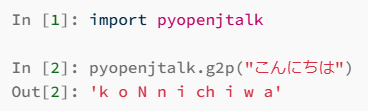

In [71]:
#Test the function for mora counts for the word "hello" in japanese:
count_mora("こんにちは") #ko-n-ni-chi-wa (the output should be 5)

5

2. Next in line we can then construct a function that **labels the haiku structure** by using the mora count:

In [72]:
def label_haiku_structure(haikus):
    """
    Takes a word-tokenized haiku (wakachigaki) and segments it into a 5-7-5 structure.
    Returns a list of (5-mora, 7-mora, 5-mora) if valid, else marks it as "Irregular."
    """
    haiku = haikus.split()
    mora_counts = [count_mora(kanji) for kanji in haiku]  # Count the mora for each word

    # Target mora structure (5-7-5)
    mora_target = [5, 7, 5]

    i = 0

    # Initialize lists for segmenting the haiku
    segments = []
    segment_mora_counts = []

    for target in mora_target:
        mora_count = 0
        phrase = []
        while i < len(haiku) and mora_count < target:
            phrase.append(haiku[i])
            mora_count += mora_counts[i]
            i += 1

        if mora_count != target:
            return [haikus, "", "", "", "Irregular"]  # Mark as irregular if it doesn't fit the 5-7-5 structure

        segments.append(" ".join(phrase))
        segment_mora_counts.append(mora_count)

    # If it matches, return the segmented haiku and classification as 'Regular'
    return [haikus, segments[0], segments[1], segments[2], "Regular"]

In [73]:
# Apply the function to our data
train_df[['haiku', '5_mora_segment_1', '7_mora_segment', '5_mora_segment_2', 'haiku_structure']] = train_df['haiku'].apply(lambda haiku: pd.Series(label_haiku_structure(haiku)))
print(f"Successfully labeled {len(train_df['haiku_structure'])} haiku! Regular: {sum(train_df['haiku_structure'] == 'Regular')} | Irregular: {sum(train_df['haiku_structure'] == 'Irregular')}")

Successfully labeled 37158 haiku! Regular: 8 | Irregular: 37150


In [74]:
train_df

,id,haiku,author,season,kigo,5_mora_segment_1,7_mora_segment,5_mora_segment_2,haiku_structure
0,1,朝霧の中に九段のともし哉,正岡子規,autumn,"{'id': 1418, 'word': '霧', 'kana': 'きり', 'seaso...",,,,Irregular
1,2,あたたかな雨が降るなり枯葎,正岡子規,winter,"{'id': 2372, 'word': '枯葎', 'kana': 'かれむぐら', 's...",,,,Irregular
2,3,菜の花やはつと明るき町はづれ,正岡子規,spring,"{'id': 496, 'word': '菜の花', 'kana': 'なのはな', 'se...",,,,Irregular
3,4,秋風や伊予へ流るる汐の音,正岡子規,autumn,"{'id': 1406, 'word': '秋風', 'kana': 'あきかぜ', 'se...",,,,Irregular
4,5,長閑さや障子の穴に海見えて,正岡子規,spring,"{'id': 32, 'word': '長閑', 'kana': 'のどか', 'seaso...",,,,Irregular
...,...,...,...,...,...,...,...,...,...
37153,41740,寒林を出づ樹にされてしまふ前,堀田季何,winter,"{'id': 2344, 'word': '寒林', 'kana': 'かんりん', 'se...",,,,Irregular
37154,41741,撃たれ吊され剥かれ剖（ひら）かれ兎われ,堀田季何,winter,"{'id': 2261, 'word': '兎', 'kana': 'うさぎ', 'seas...",,,,Irregular
37155,41742,日の本の中心や色変へぬ松,堀田季何,autumn,"{'id': 1696, 'word': '色変へぬ松', 'kana': 'いろかえぬまつ...",,,,Irregular
37156,41743,泳ぐなり水没都市の青空を,堀田季何,summer,"{'id': 851, 'word': '泳ぎ', 'kana': 'およぎ', 'seas...",,,,Irregular


Now we have the haiku labeled and also separated in 5-7-5 structure if Regular.

***Separating the `train split` from the `kigo dictionary`*** to use later for the tokenization

In [75]:
# Rename 'id' in train_df to 'haiku_id' to distinguish from kigo_id
train_df.rename(columns={'id': 'haiku_id'}, inplace=True)

kigo_df = train_df[['haiku_id', 'kigo']].copy()

# Rename 'id' inside kigo dictionary to 'kigo_id'
kigo_df = kigo_df.join(kigo_df.pop('kigo').apply(pd.Series).rename(columns={'id': 'kigo_id'}))

kigo_df['kigo_id'] = pd.to_numeric(kigo_df['kigo_id'], errors='coerce').astype('Int64')

train_df.drop(columns=['kigo'], inplace=True)

print("train_df (without kigo):\n")
display(train_df)
print("kigo_df :\n")
display(kigo_df)

train_df (without kigo):



,haiku_id,haiku,author,season,5_mora_segment_1,7_mora_segment,5_mora_segment_2,haiku_structure
0,1,朝霧の中に九段のともし哉,正岡子規,autumn,,,,Irregular
1,2,あたたかな雨が降るなり枯葎,正岡子規,winter,,,,Irregular
2,3,菜の花やはつと明るき町はづれ,正岡子規,spring,,,,Irregular
3,4,秋風や伊予へ流るる汐の音,正岡子規,autumn,,,,Irregular
4,5,長閑さや障子の穴に海見えて,正岡子規,spring,,,,Irregular
...,...,...,...,...,...,...,...,...
37153,41740,寒林を出づ樹にされてしまふ前,堀田季何,winter,,,,Irregular
37154,41741,撃たれ吊され剥かれ剖（ひら）かれ兎われ,堀田季何,winter,,,,Irregular
37155,41742,日の本の中心や色変へぬ松,堀田季何,autumn,,,,Irregular
37156,41743,泳ぐなり水没都市の青空を,堀田季何,summer,,,,Irregular


kigo_df :



,haiku_id,kigo_id,word,kana,season,subtitle
0,1,1418,霧,きり,autumn,"[朝霧, 夕霧, 夜霧, 山霧, 川霧, 狭霧, 霧襖, 霧雨, 濃霧, 霧笛]"
1,2,2372,枯葎,かれむぐら,winter,[]
2,3,496,菜の花,なのはな,spring,"[花菜, 菜種の花, 油菜, 菜種菜, 花菜雨, 花菜風]"
3,4,1406,秋風,あきかぜ,autumn,"[秋風, 秋の風, 金風, 爽籟, 色なき風, 律の風]"
4,5,32,長閑,のどか,spring,"[長閑さ, のどけし, のどけさ]"
...,...,...,...,...,...,...
37153,41740,2344,寒林,かんりん,winter,[寒木]
37154,41741,2261,兎,うさぎ,winter,[兎汁]
37155,41742,1696,色変へぬ松,いろかえぬまつ,autumn,[]
37156,41743,851,泳ぎ,およぎ,summer,"[水泳, 水練, 遊泳, 競泳, 遠泳, ダイビング, 浮輪]"


### **Check some information about the haiku**

In [76]:
#How many and which author are present in this dataset?
authors = train_df['author']

unique_authors = authors.unique()
num_unique_authors = len(unique_authors)

print(f"Total number of unique authors: {num_unique_authors}")
print("List of unique authors:")
for author in unique_authors:
    print(author)


Total number of unique authors: 4625
List of unique authors:
正岡子規
内藤鳴雪
夏目漱石
芥川龍之介
松瀬青々
高浜虚子
河東碧梧桐
臼田亞浪
村上鬼城
松根東洋城
渡邊水巴
飯田蛇笏
前田普羅
原石鼎
水原秋櫻子
高野素十
阿波野青畝
山口誓子
荻原井泉水
中塚一碧樓
種田山頭火
尾崎放哉
長谷川かな女
室生犀星
久保田万太郎
富安風生
山口青邨
富田木歩
日野草城
杉田久女
相生垣瓜人
中村草田男
加藤楸邨
中村汀女
星野立子
川端茅舎
松本たかし
皆吉爽雨
後藤夜半
石田波郷
芝不器男
篠原鳳作
富澤赤黄男
高屋窓秋
三橋鷹女
西東三鬼
渡辺白泉
野見山朱鳥
木下夕爾
大野林火
橋本多佳子
永田耕衣
橋閒石
秋元不死男
平畑静塔
細見綾子
安住敦
相馬遷子
石川桂郎
篠原梵
下村槐太
能村登四郎
桂信子
角川源義
森澄雄
金子兜太
佐藤鬼房
鈴木六林男
沢木欣一
石原八束
松崎鉄之介
村越化石
野澤節子
草間時彦
飯田龍太
三橋敏雄
上村占魚
清崎敏郎
高柳重信
山川蟬夫
赤尾兜子
津田清子
中村苑子
飯島晴子
波多野爽波
藤田湘子
飴山實
宇佐美魚目
川崎展宏
阿部完市
岡本眸
加藤郁乎
鷹羽狩行
河原枇杷男
原裕
有馬朗人
稲畑汀子
上田五千石
平井照敏
寺山修司
福永耕二
矢島渚男
黒田杏子
角川春樹
坪内稔典
攝津幸彦
中原道夫
長谷川櫂
夏石番矢
小澤實
田中裕明
岸本尚毅
井上井月
石井露月
青木月斗
岡本松浜
大須賀乙字
鈴木花蓑
野村泊月
嶋田青峰
清原枴童
高田蝶衣
阿部みどり女
野村喜舟
松村蒼石
鈴鹿野風呂
池内たけし
吉岡禅寺洞
大場白水郎
尾崎迷堂
軽部烏頭子
島村元
栗林一石路
西島麦南
長谷川双魚
山口草堂
三宅清三郎
篠田悌二郎
横山白虹
及川貞
右城暮石
金尾梅の門
高浜年尾
瀧春一
海藤抱壺
橋本夢道
武原はん女
百合山羽公
福田蓼汀
池内友次郎
石塚友二
長谷川素逝
細谷源二
山口波津女
柴田白葉女
鈴木真砂女
中川宋淵
橋本鶏二
谷野予志
赤城さかえ
殿村菟絲子
藤後左右
京極杞陽
石橋辰之助
石橋秀野
中島斌雄
岸風三楼
三谷昭
神生彩史
清水径子
火渡周平
古沢太穂
田川飛旅子
後藤綾子
斎藤玄
阿部青鞋
林翔
中尾寿美子
上野泰
香西照雄
後藤比奈夫
岸

> According to ChatGPT 105 of them are recognized famous haiku poets, so we can see how many of their haikus are present in this dataset:

In [77]:
# Count occurrences (haiku per author)
author_counts = train_df['author'].value_counts().reset_index()
author_counts = author_counts.rename(columns={'index': 'author', 0: 'haiku_count'})

print(f"Number of haiku per author, in descending order: \n {display(author_counts.head(50))}")

,author,count
0,桂信子,950
1,金子兜太,352
2,松澤昭,267
3,和知喜八,209
4,高浜虚子,204
5,吉田未灰,166
6,宇多喜代子,151
7,中村和弘,147
8,西島麦南,144
9,藤田湘子,131


Number of haiku per author, in descending order: 
 None


### **Tokenize the dataset**

To tokenize Japanese poetry, it's recommended to use [MeCab](https://pypi.org/project/mecab-python3/) (with the UniDic dictionary, which is ideal for poetry and provides easy Python integration with fugashi) along with a kigo dictionary (季語), which, based on the words in the haiku, categorizes it by season. Conveniently, this kigo dictionary is included in the HuggingFace dataset we selected.

In [78]:
#kigo words
kigo_words = set(kigo_df['word'].values)

#Initialize the MeCab tagger with '-Owakati' to split tokens by spaces
tagger = fugashi.Tagger('-Owakati')

#Function to tokenize the haiku and identify kigo words
def process_haiku(haiku):
    tokens = tagger.parse(haiku).strip().split()
    kigo_in_haiku = [word for word in tokens if word in kigo_words] #To identify kigo words in the haiku

    return tokens, kigo_in_haiku

train_df[['tokenized_haiku', 'kigo_words']] = train_df['haiku'].apply(lambda haiku: pd.Series(process_haiku(haiku)))
display(train_df[['haiku', 'tokenized_haiku', 'kigo_words']])

,haiku,tokenized_haiku,kigo_words
0,朝霧の中に九段のともし哉,"[朝霧, の, 中, に, 九, 段, の, ともし, 哉]",[]
1,あたたかな雨が降るなり枯葎,"[あたたか, な, 雨, が, 降る, なり, 枯, 葎]",[]
2,菜の花やはつと明るき町はづれ,"[菜の花, や, は, つと, 明る, き, 町, は, づれ]",[菜の花]
3,秋風や伊予へ流るる汐の音,"[秋風, や, 伊予, へ, 流るる, 汐, の, 音]",[秋風]
4,長閑さや障子の穴に海見えて,"[長閑, さ, や, 障子, の, 穴, に, 海, 見え, て]","[長閑, 障子]"
...,...,...,...
37153,寒林を出づ樹にされてしまふ前,"[寒, 林, を, 出づ, 樹, に, さ, れ, て, しまふ, 前]",[寒]
37154,撃たれ吊され剥かれ剖（ひら）かれ兎われ,"[撃た, れ, 吊さ, れ, 剥か, れ, 剖, （, ひら, ）, かれ, 兎, われ]",[兎]
37155,日の本の中心や色変へぬ松,"[日の本, の, 中心, や, 色, 変へ, ぬ, 松]",[]
37156,泳ぐなり水没都市の青空を,"[泳ぐ, なり, 水没, 都市, の, 青空, を]",[]


# *CONTROLLARE LA TOKENIZZAZIONE, ALCUNI HAIKU HANNO PAROLE SPEZZATE CHE NON DOVREBBERO ESSERE DIVISE IN QUEL MODO*

In [79]:
# Merge seasonal information for the kigo words into the main DataFrame
def get_seasons_from_kigo(kigo_words):
    seasons = []
    for word in kigo_words:
        # Find the corresponding season from kigo_df
        season = kigo_df[kigo_df['word'] == word]['season'].values
        if season.size > 0:
            seasons.append(season[0])  # If kigo word found, get the season
    return seasons

#New column for the kigo seasons
train_df['kigo_seasons'] = train_df['kigo_words'].apply(get_seasons_from_kigo)

display(train_df[['haiku', 'tokenized_haiku', 'kigo_words', 'kigo_seasons']])

,haiku,tokenized_haiku,kigo_words,kigo_seasons
0,朝霧の中に九段のともし哉,"[朝霧, の, 中, に, 九, 段, の, ともし, 哉]",[],[]
1,あたたかな雨が降るなり枯葎,"[あたたか, な, 雨, が, 降る, なり, 枯, 葎]",[],[]
2,菜の花やはつと明るき町はづれ,"[菜の花, や, は, つと, 明る, き, 町, は, づれ]",[菜の花],[spring]
3,秋風や伊予へ流るる汐の音,"[秋風, や, 伊予, へ, 流るる, 汐, の, 音]",[秋風],[autumn]
4,長閑さや障子の穴に海見えて,"[長閑, さ, や, 障子, の, 穴, に, 海, 見え, て]","[長閑, 障子]","[spring, winter]"
...,...,...,...,...
37153,寒林を出づ樹にされてしまふ前,"[寒, 林, を, 出づ, 樹, に, さ, れ, て, しまふ, 前]",[寒],[winter]
37154,撃たれ吊され剥かれ剖（ひら）かれ兎われ,"[撃た, れ, 吊さ, れ, 剥か, れ, 剖, （, ひら, ）, かれ, 兎, われ]",[兎],[winter]
37155,日の本の中心や色変へぬ松,"[日の本, の, 中心, や, 色, 変へ, ぬ, 松]",[],[]
37156,泳ぐなり水没都市の青空を,"[泳ぐ, なり, 水没, 都市, の, 青空, を]",[],[]


## **Pre-trained embeddings?**